# TrappyTV Examplar notebook

In [19]:
# Source - https://stackoverflow.com/a/10472712
# Posted by Andrew_1510, modified by community. See post 'Timeline' for change history
# Retrieved 2026-05-04, License - CC BY-SA 4.0

%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [20]:
# Import Packages
import os
import sys
import numpy as np
import pandas as pd

In [21]:
## Import Bokeh module and TrappyTV class
from bokeh.io import output_notebook
output_notebook()

import sys
sys.path.append(os.path.dirname(os.getcwd()))
from trappytv import CellView


Loading BokehJS ...

## Import Data

In [22]:
#datapaths = ["../data/merged_tracks.hd5"]
#datapaths = ["data/2026_01_02/m2_merged_tracks.hd5"]
datapaths = ["../data/2025_12_30/M4_2025_12_30.hd5"]

In [23]:
import matplotlib.pyplot as plt
stack = np.load("../data/2025_12_30/first_frames_M4_2025_12_30.npy", mmap_mode="r")
first_frame = stack[0]

In [24]:
cell = CellView(datapaths[0], compute_speed=True)
cell()

[INIT] datapath=../data/2025_12_30/M4_2025_12_30.hd5
[PROTECTED] {'split', 'particle', 'frame', 'scopeid', 'dt'}
[HDF_KEYS] ['df', 'metadata', 'xyr_df']
[MAIN_KEY] df
[LOAD] tracks loaded
[LOAD] xyr_df loaded
[LOAD] metadata loaded (metadata)
[SPEED] grouped: ['split', 'particle']


/Users/byatharth/code/Trappy-Scopes/trappytv/trappytv/cellview.py:208: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series(compute(g), index=g.index))


,relative_ms_timestamp,tpts_gap,frame,split,dt,gframe,dt_diff,elapsed_seconds,elapsed_frames,x,...,ep_unrefined,x_argmax,y_argmax,particle,raw_mean,bgs_mean,temp,humidity,failed_split,speed
0,0.000000e+00,False,0,0,2025-12-30 12:06:18.856990986,0,NaT,NaN,0,413.344727,...,0.133549,413.0,1051.0,0,0.079190,0.001098,21.61064,47.580528,False,0.904629
1,3.999200e+01,False,1,0,2025-12-30 12:06:18.896982987,1,0 days 00:00:00.039992001,0.039992,1,412.197955,...,0.194263,413.0,1053.0,0,0.079150,0.001096,21.61064,47.580528,False,0.850569
2,7.998900e+01,False,2,0,2025-12-30 12:06:18.936979984,2,0 days 00:00:00.039996997,0.039997,1,413.534287,...,0.134918,413.0,1053.0,0,0.079297,0.001095,21.61064,47.580528,False,0.772239
3,1.199820e+02,False,3,0,2025-12-30 12:06:18.976972988,3,0 days 00:00:00.039993004,0.039993,1,414.611895,...,0.137866,414.0,1054.0,0,0.079131,0.001100,21.61064,47.580528,False,0.722110
4,1.599770e+02,False,4,0,2025-12-30 12:06:19.016967991,4,0 days 00:00:00.039995003,0.039995,1,414.618575,...,0.147200,414.0,1055.0,0,0.079267,0.001100,21.61064,47.580528,False,1.174004
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
480191,1.920513e+07,False,15001,31,2025-12-30 17:26:23.982990986,480191,0 days 00:00:00.040000,0.040000,1,703.650822,...,0.174098,703.0,837.0,0,0.080349,0.001113,22.37701,47.851280,False,0.235382
480192,1.920517e+07,False,15002,31,2025-12-30 17:26:24.022990986,480192,0 days 00:00:00.040000,0.040000,1,702.521423,...,0.270291,703.0,837.0,0,0.080360,0.001116,22.37701,47.851280,False,0.071603
480193,1.920521e+07,False,15003,31,2025-12-30 17:26:24.062990986,480193,0 days 00:00:00.040000,0.040000,1,701.487766,...,0.241408,703.0,837.0,0,0.080344,0.001117,22.37701,47.851280,False,0.055677
480194,1.920525e+07,False,15004,31,2025-12-30 17:26:24.102990986,480194,0 days 00:00:00.040000,0.040000,1,703.391415,...,0.161789,703.0,837.0,0,0.080355,0.001117,22.37701,47.851280,False,0.198771


## Do some post-processing

In [25]:
from analysis.outliers import drop_edge_nans_and_interpolate
cell.add_columns(inputs=["x_unrefined", "y_unrefined"], func=drop_edge_nans_and_interpolate, outputs=["xf_", "yf_"], max_length=3) ## To use 3rd order polynomial interpolation later.
print(cell().postprocess.unique())
cell()


[ADD_COL] ['x_unrefined', 'y_unrefined'] -> ['xf_', 'yf_', 'postprocess']
[None 'filled' 'missing']


,relative_ms_timestamp,tpts_gap,frame,split,dt,gframe,dt_diff,elapsed_seconds,elapsed_frames,x,...,particle,raw_mean,bgs_mean,temp,humidity,failed_split,speed,xf_,yf_,postprocess
0,0.000000e+00,False,0,0,2025-12-30 12:06:18.856990986,0,NaT,NaN,0,413.344727,...,0,0.079190,0.001098,21.61064,47.580528,False,0.904629,413.001387,1052.032283,None
1,3.999200e+01,False,1,0,2025-12-30 12:06:18.896982987,1,0 days 00:00:00.039992001,0.039992,1,412.197955,...,0,0.079150,0.001096,21.61064,47.580528,False,0.850569,413.731773,1052.566035,None
2,7.998900e+01,False,2,0,2025-12-30 12:06:18.936979984,2,0 days 00:00:00.039996997,0.039997,1,413.534287,...,0,0.079297,0.001095,21.61064,47.580528,False,0.772239,413.823451,1053.521605,None
3,1.199820e+02,False,3,0,2025-12-30 12:06:18.976972988,3,0 days 00:00:00.039993004,0.039993,1,414.611895,...,0,0.079131,0.001100,21.61064,47.580528,False,0.722110,414.224940,1054.029661,None
4,1.599770e+02,False,4,0,2025-12-30 12:06:19.016967991,4,0 days 00:00:00.039995003,0.039995,1,414.618575,...,0,0.079267,0.001100,21.61064,47.580528,False,1.174004,414.457885,1054.819013,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
480191,1.920513e+07,False,15001,31,2025-12-30 17:26:23.982990986,480191,0 days 00:00:00.040000,0.040000,1,703.650822,...,0,0.080349,0.001113,22.37701,47.851280,False,0.235382,702.975426,837.291399,None
480192,1.920517e+07,False,15002,31,2025-12-30 17:26:24.022990986,480192,0 days 00:00:00.040000,0.040000,1,702.521423,...,0,0.080360,0.001116,22.37701,47.851280,False,0.071603,702.780966,837.123152,None
480193,1.920521e+07,False,15003,31,2025-12-30 17:26:24.062990986,480193,0 days 00:00:00.040000,0.040000,1,701.487766,...,0,0.080344,0.001117,22.37701,47.851280,False,0.055677,703.059667,837.407207,None
480194,1.920525e+07,False,15004,31,2025-12-30 17:26:24.102990986,480194,0 days 00:00:00.040000,0.040000,1,703.391415,...,0,0.080355,0.001117,22.37701,47.851280,False,0.198771,702.841189,837.029488,None


### Outlier detection

In [26]:
large_uncertainty = [event for event in events if event["type"] == "large_uncertainty"]
print([int(l["n_bad_points"]) for l in large_uncertainty])
print([int(l["anchor_after"]-l["anchor_before"]) for l in large_uncertainty])


[3, 1, 9, 2, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 2, 1, 3, 1, 1, 1, 1, 1, 1, 1, 2, 1, 7, 1, 5, 1, 2, 1, 1, 1, 1, 3, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 3, 1, 1, 1, 1, 1, 9, 1, 1, 1, 1, 1, 1, 4, 3, 1, 1, 3, 6, 1, 3]
[4, 2, 10, 3, 2, 2, 2, 2, 2, 3, 2, 2, 2, 2, 3, 2, 4, 2, 2, 2, 2, 2, 2, 2, 3, 2, 8, 2, 6, 2, 3, 2, 2, 2, 2, 4, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 4, 2, 2, 2, 2, 2, 10, 2, 2, 2, 2, 2, 2, 5, 4, 2, 2, 4, 7, 2, 4]


In [27]:
from analysis.outliers import detect_outliers_local, mark_events_in_postprocess, interpolate_large_uncertainty
events = detect_outliers_local(cell(), xcol="xf_", ycol="yf_", no_tbins=500)
cell.stuff["events"] = events
print("All events: ", len(events))
print("All events with large uncertainity: ", len([event for event in events if event["type"] == "large_uncertainty"]))
cell.add_columns(func=mark_events_in_postprocess, inputs = ["postprocess"], outputs = ["postprocess"], inplace=True, events=events)
cell.add_columns(func=interpolate_large_uncertainty, inputs = ["xf_", "yf_", "postprocess"], outputs = ["xf", "yf", "postprocess"], inplace=True, events=events)
print(cell().postprocess.unique()) 
cell()
      


All events:  1890
All events with large uncertainity:  69
[ADD_COL] ['postprocess'] -> []
[ADD_COL] ['xf_', 'yf_', 'postprocess'] -> ['xf', 'yf']
[None 'filled' 'large_disp' nan 'missing']


,relative_ms_timestamp,tpts_gap,frame,split,dt,gframe,dt_diff,elapsed_seconds,elapsed_frames,x,...,bgs_mean,temp,humidity,failed_split,speed,xf_,yf_,postprocess,xf,yf
0,0.000000e+00,False,0,0,2025-12-30 12:06:18.856990986,0,NaT,NaN,0,413.344727,...,0.001098,21.61064,47.580528,False,0.904629,413.001387,1052.032283,None,413.001387,1052.032283
1,3.999200e+01,False,1,0,2025-12-30 12:06:18.896982987,1,0 days 00:00:00.039992001,0.039992,1,412.197955,...,0.001096,21.61064,47.580528,False,0.850569,413.731773,1052.566035,None,413.731773,1052.566035
2,7.998900e+01,False,2,0,2025-12-30 12:06:18.936979984,2,0 days 00:00:00.039996997,0.039997,1,413.534287,...,0.001095,21.61064,47.580528,False,0.772239,413.823451,1053.521605,None,413.823451,1053.521605
3,1.199820e+02,False,3,0,2025-12-30 12:06:18.976972988,3,0 days 00:00:00.039993004,0.039993,1,414.611895,...,0.001100,21.61064,47.580528,False,0.722110,414.224940,1054.029661,None,414.224940,1054.029661
4,1.599770e+02,False,4,0,2025-12-30 12:06:19.016967991,4,0 days 00:00:00.039995003,0.039995,1,414.618575,...,0.001100,21.61064,47.580528,False,1.174004,414.457885,1054.819013,None,414.457885,1054.819013
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
480191,1.920513e+07,False,15001,31,2025-12-30 17:26:23.982990986,480191,0 days 00:00:00.040000,0.040000,1,703.650822,...,0.001113,22.37701,47.851280,False,0.235382,702.975426,837.291399,None,702.975426,837.291399
480192,1.920517e+07,False,15002,31,2025-12-30 17:26:24.022990986,480192,0 days 00:00:00.040000,0.040000,1,702.521423,...,0.001116,22.37701,47.851280,False,0.071603,702.780966,837.123152,None,702.780966,837.123152
480193,1.920521e+07,False,15003,31,2025-12-30 17:26:24.062990986,480193,0 days 00:00:00.040000,0.040000,1,701.487766,...,0.001117,22.37701,47.851280,False,0.055677,703.059667,837.407207,None,703.059667,837.407207
480194,1.920525e+07,False,15004,31,2025-12-30 17:26:24.102990986,480194,0 days 00:00:00.040000,0.040000,1,703.391415,...,0.001117,22.37701,47.851280,False,0.198771,702.841189,837.029488,None,702.841189,837.029488


In [28]:
from analysis.sg import apply_sg_bf_on_xy, hodrick_prescott_on_xy
cell.add_columns(inputs=["xf", "yf"], func=apply_sg_bf_on_xy, outputs=["xf_11Hz", "yf_11Hz"], inplace=False, window_length=3, polyorder=2)
cell.add_columns(inputs=["xf_11Hz", "yf_11Hz"], func=apply_sg_bf_on_xy, outputs=["xf_3Hz", "yf_3Hz"], inplace=False, window_length=7, polyorder=3)
#cell.add_columns(inputs=["xf_3Hz", "yf_3Hz"], func=apply_sg_bf_on_xy, outputs=["xf_long", "yf_long"], inplace=False, window_length=151, polyorder=2)

cell.add_columns(inputs=["xf_3Hz", "yf_3Hz"], func=hodrick_prescott_on_xy, outputs=["xf_long", "yf_long"], inplace=False, lambda_smooth=1e4, 
                 interpolate_if_necessary=True, include_cycles=True)
cell()

[ADD_COL] ['xf', 'yf'] -> ['xf_11Hz', 'yf_11Hz']
[ADD_COL] ['xf_11Hz', 'yf_11Hz'] -> ['xf_3Hz', 'yf_3Hz']
[ADD_COL] ['xf_3Hz', 'yf_3Hz'] -> ['xf_long', 'yf_long', 'x_cycle', 'y_cycle']


,relative_ms_timestamp,tpts_gap,frame,split,dt,gframe,dt_diff,elapsed_seconds,elapsed_frames,x,...,xf,yf,xf_11Hz,yf_11Hz,xf_3Hz,yf_3Hz,xf_long,yf_long,x_cycle,y_cycle
0,0.000000e+00,False,0,0,2025-12-30 12:06:18.856990986,0,NaT,NaN,0,413.344727,...,413.001387,1052.032283,413.001387,1052.032283,413.001387,1052.032283,412.087579,1052.681093,0.913808,-0.648810
1,3.999200e+01,False,1,0,2025-12-30 12:06:18.896982987,1,0 days 00:00:00.039992001,0.039992,1,412.197955,...,413.731773,1052.566035,413.731773,1052.566035,413.510350,1052.657295,412.598414,1053.424613,0.911936,-0.767318
2,7.998900e+01,False,2,0,2025-12-30 12:06:18.936979984,2,0 days 00:00:00.039996997,0.039997,1,413.534287,...,413.823451,1053.521605,413.823451,1053.521605,413.899081,1053.374722,413.109341,1054.168068,0.789740,-0.793346
3,1.199820e+02,False,3,0,2025-12-30 12:06:18.976972988,3,0 days 00:00:00.039993004,0.039993,1,414.611895,...,414.224940,1054.029661,414.224940,1054.029661,414.180493,1054.160311,413.620542,1054.911316,0.559951,-0.751005
4,1.599770e+02,False,4,0,2025-12-30 12:06:19.016967991,4,0 days 00:00:00.039995003,0.039995,1,414.618575,...,414.457885,1054.819013,414.457885,1054.819013,414.376354,1055.056110,414.132278,1055.654137,0.244076,-0.598027
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
480191,1.920513e+07,False,15001,31,2025-12-30 17:26:23.982990986,480191,0 days 00:00:00.040000,0.040000,1,703.650822,...,702.975426,837.291399,702.975426,837.291399,703.029858,837.252409,703.058885,837.142666,-0.029027,0.109743
480192,1.920517e+07,False,15002,31,2025-12-30 17:26:24.022990986,480192,0 days 00:00:00.040000,0.040000,1,702.521423,...,702.780966,837.123152,702.780966,837.123152,702.951948,837.250664,703.064250,837.147586,-0.112302,0.103079
480193,1.920521e+07,False,15003,31,2025-12-30 17:26:24.062990986,480193,0 days 00:00:00.040000,0.040000,1,701.487766,...,703.059667,837.407207,703.059667,837.407207,702.915869,837.218391,703.069532,837.152464,-0.153663,0.065927
480194,1.920525e+07,False,15004,31,2025-12-30 17:26:24.102990986,480194,0 days 00:00:00.040000,0.040000,1,703.391415,...,702.841189,837.029488,702.841189,837.029488,702.911444,837.128535,703.074774,837.157311,-0.163330,-0.028777


In [ ]:
cell().postprocess.unique()

# Outliers

NameError: name 'sns' is not defined

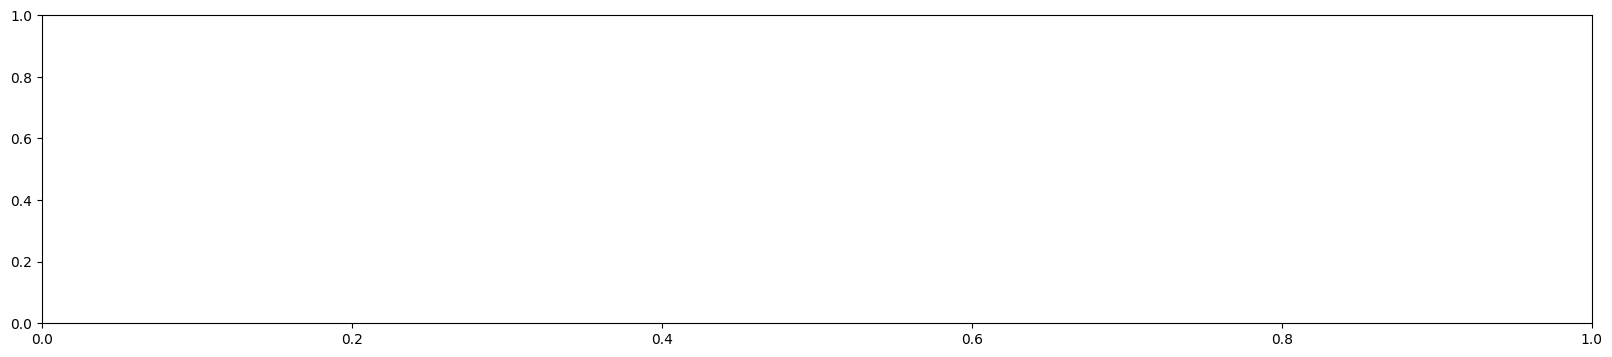

In [29]:
#plt.boxplot([cell().ep_unrefined.dropna(), cell().ep.dropna()], showfliers=False)
fig, (ax) = plt.subplots(figsize=(20,4), nrows=1, sharex=True)
df = cell().copy()
df["tbin"] = pd.cut(df["gframe"], bins=100, labels=False)
sns.boxplot(data=df, y="ep_unrefined", x="tbin", showfliers=False, ax=ax, log_scale=False)
ax.axhline(df.ep_unrefined.median(), c="red", linestyle="--", label=f"Global median: {df.ep_unrefined.median():.2f}px")

#sns.boxplot(data=df, y="size_unrefined", x="tbin", showfliers=False, ax=ax2, log_scale=False)
#sns.boxplot(data=df, y="signal_unrefined", x="tbin", showfliers=False, ax=ax3, log_scale=False)

step = 10

ticks = ax.get_xticks()
labels = [t.get_text() for t in ax.get_xticklabels()]

ax.set_xticks(ticks[::step])
ax.set_xticklabels(labels[::step])
plt.legend()
fig.savefig("ep_unrefined.pdf", bbox_inches="tight")


NameError: name 'sns' is not defined

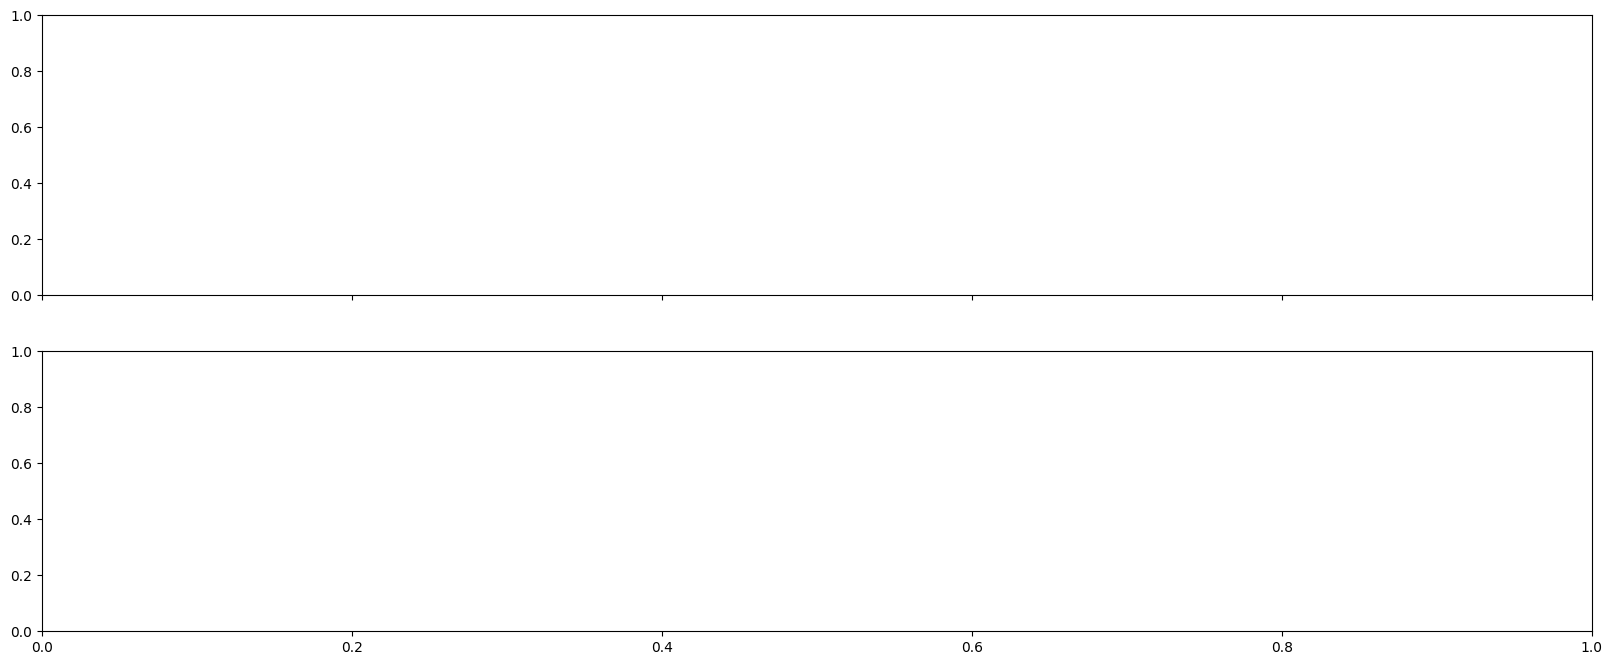

In [30]:
#plt.boxplot([cell().ep_unrefined.dropna(), cell().ep.dropna()], showfliers=False)
fig, (ax, ax2) = plt.subplots(figsize=(20,4*2), nrows=2, sharex=True)
df = cell().copy()
df["tbin"] = pd.cut(df["gframe"], bins=100, labels=False)
sns.boxplot(data=df, y="ep_unrefined", x="tbin", showfliers=False, ax=ax, log_scale=False)
ax.axhline(df.ep_unrefined.median(), c="red", linestyle="--", label=f"Global median: {df.ep_unrefined.median():.2f}px")

sns.boxplot(data=df, y="speed", x="tbin", showfliers=False, ax=ax2, log_scale=False)
#sns.boxplot(data=df, y="signal_unrefined", x="tbin", showfliers=False, ax=ax3, log_scale=False)

step = 10

ticks = ax.get_xticks()
labels = [t.get_text() for t in ax.get_xticklabels()]

ax.set_xticks(ticks[::step])
ax.set_xticklabels(labels[::step])
plt.legend()


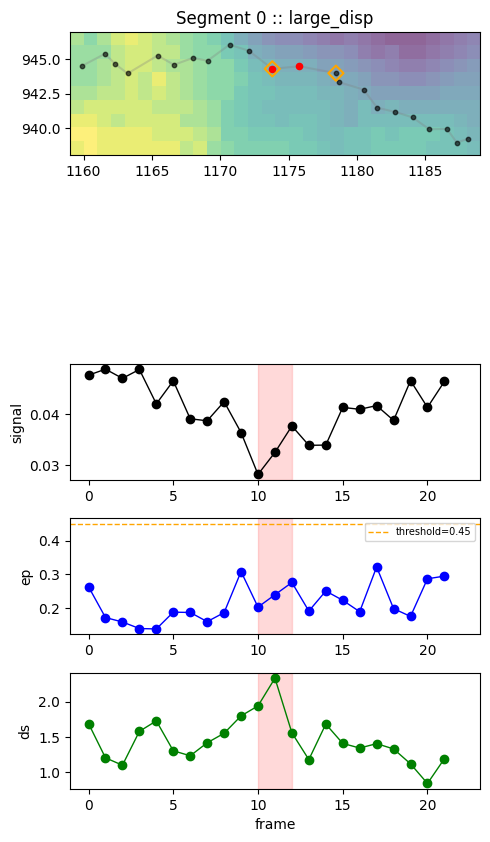

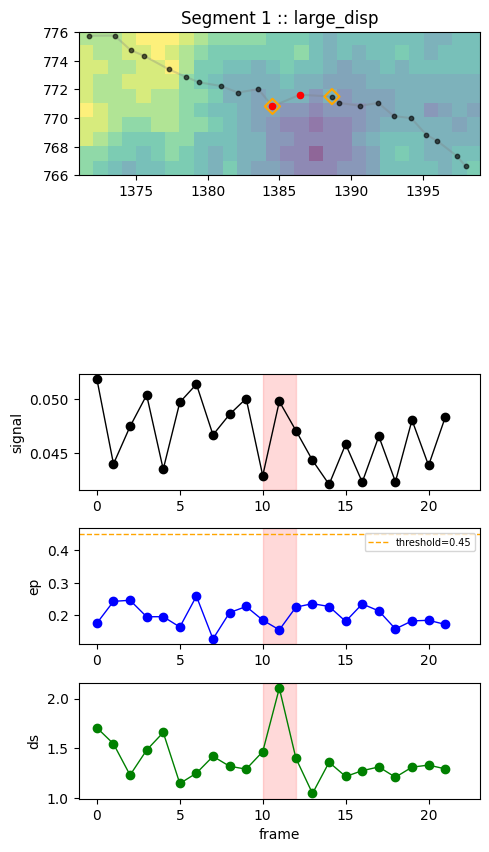

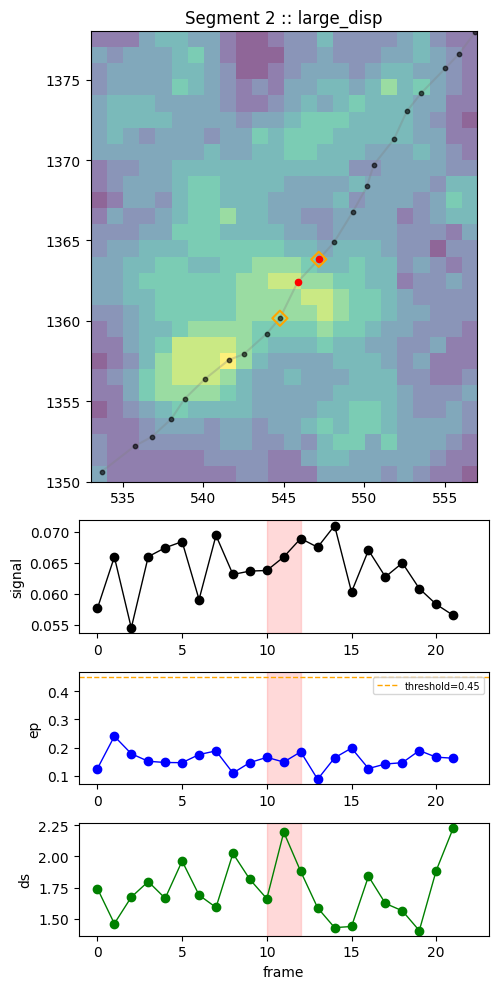

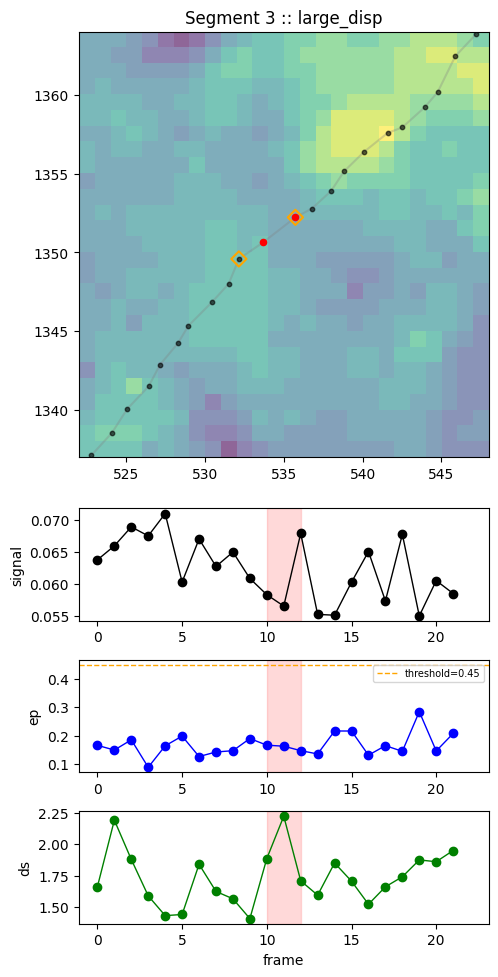

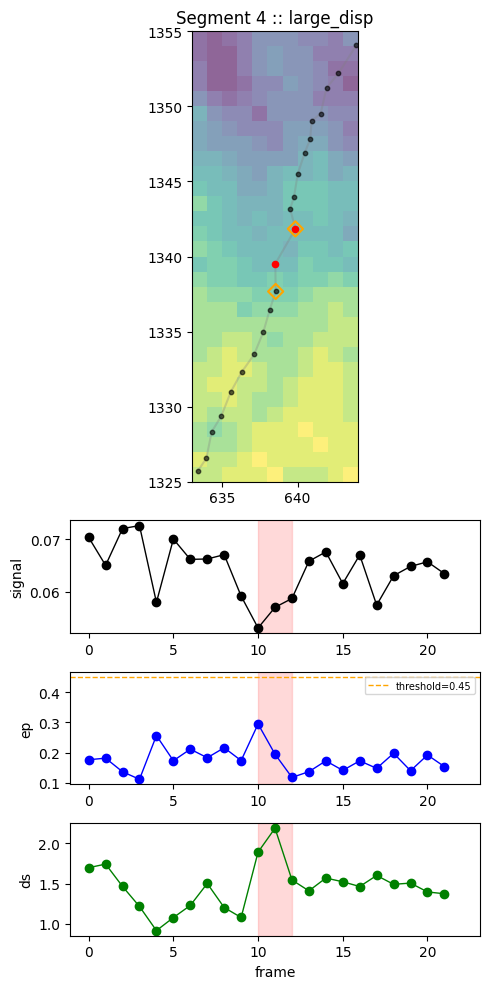

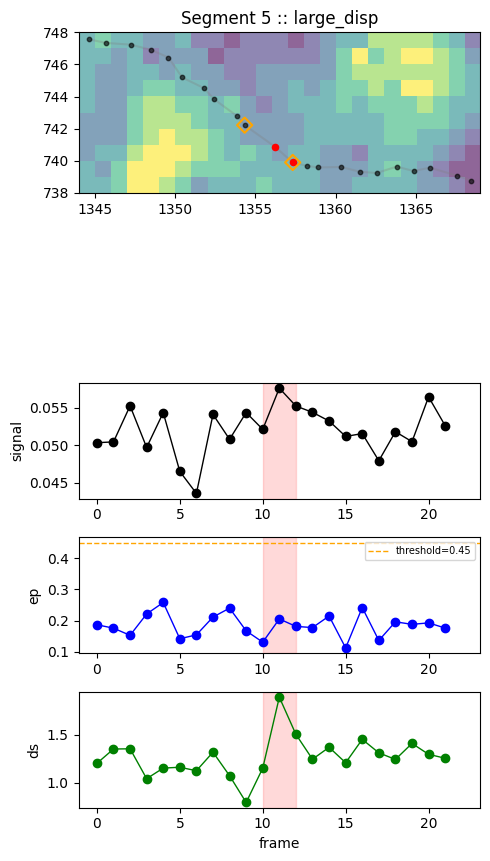

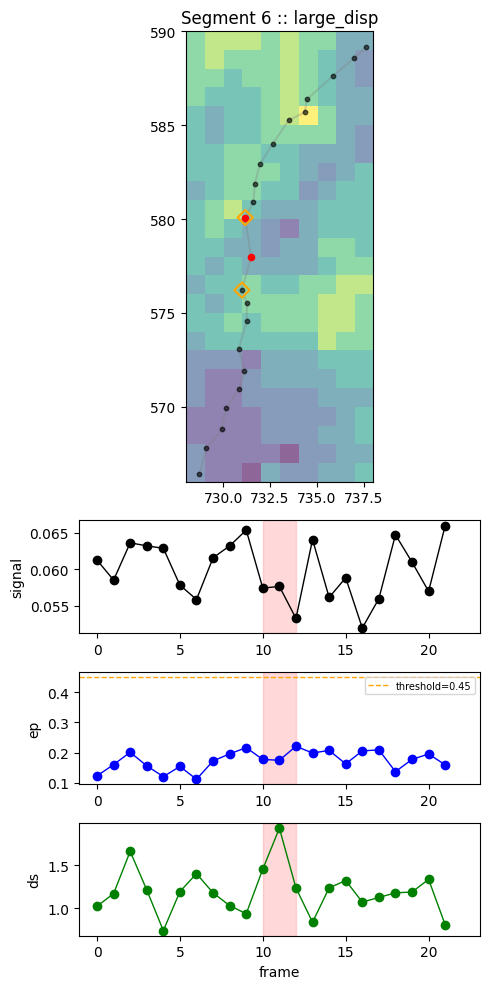

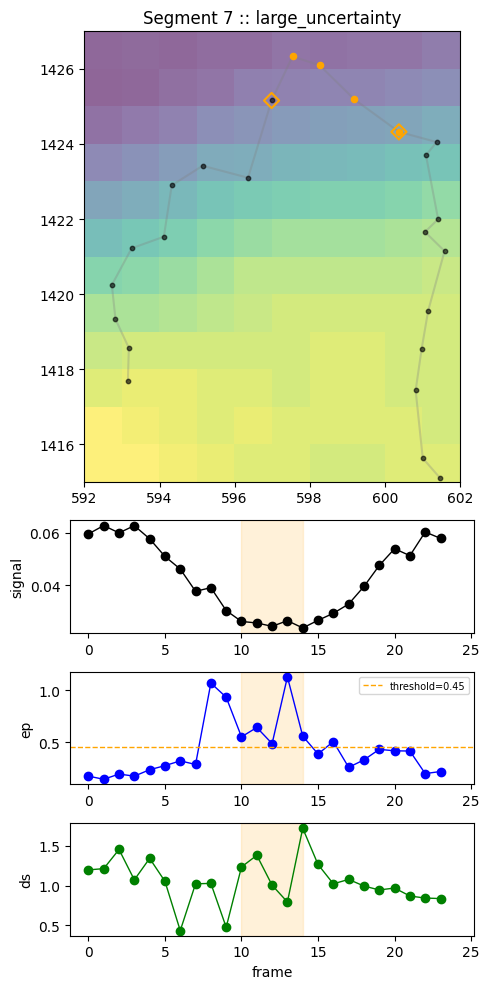

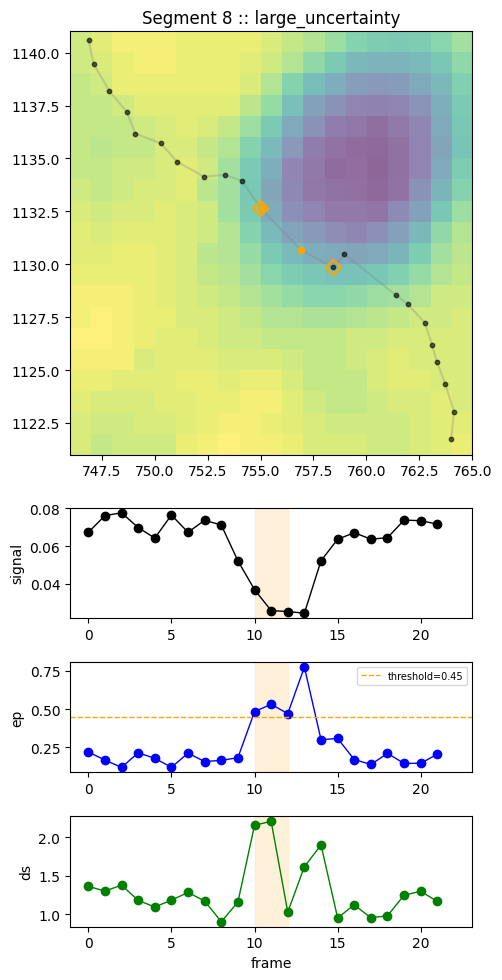

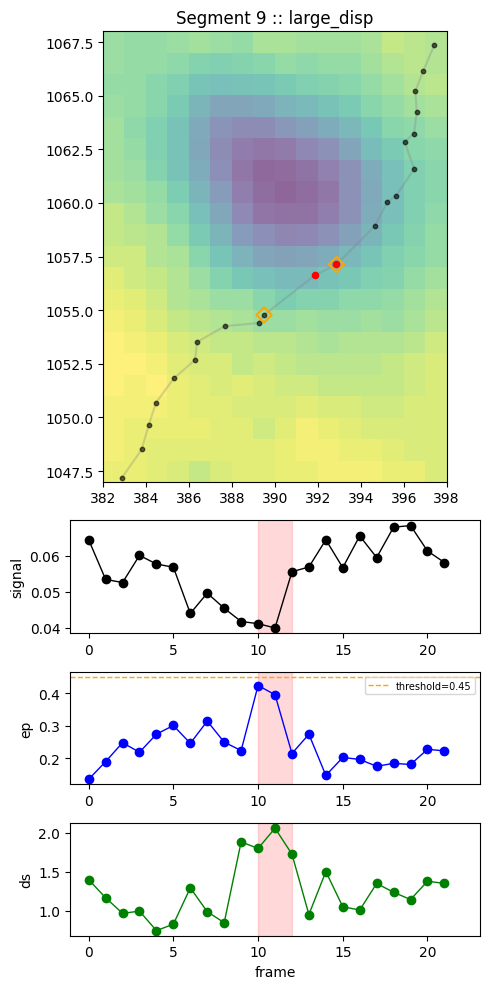

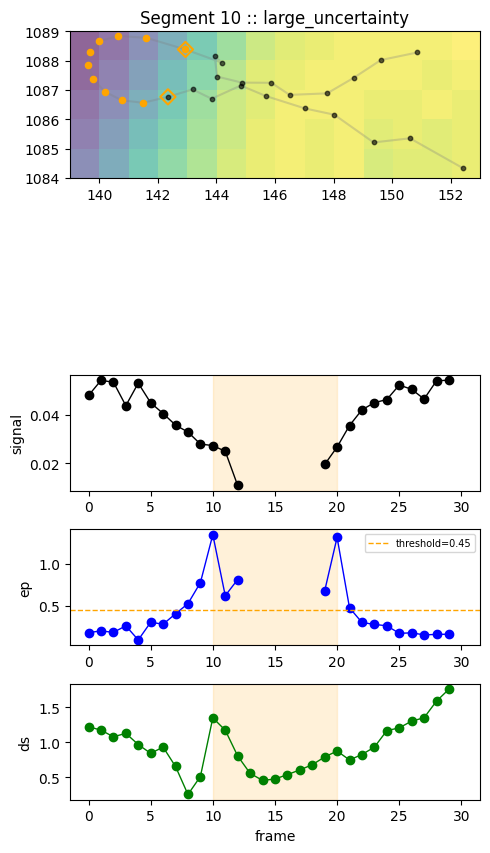

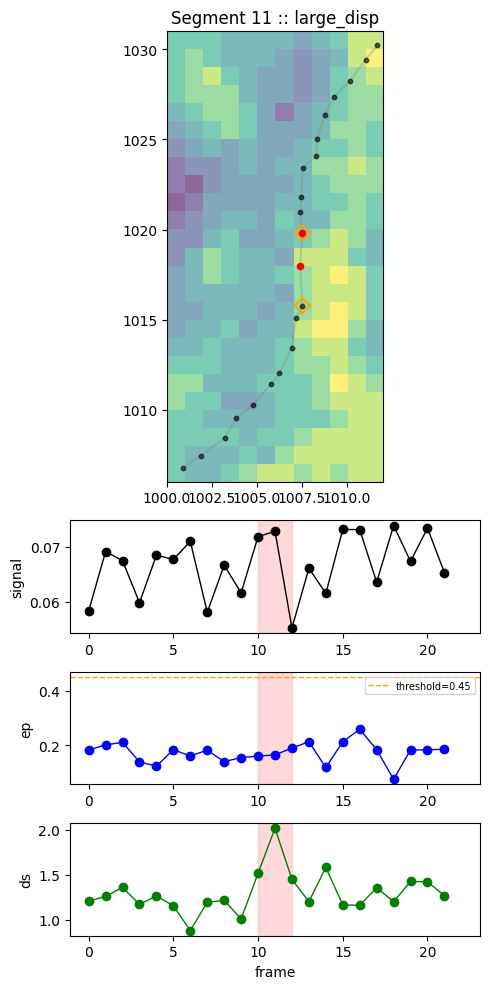

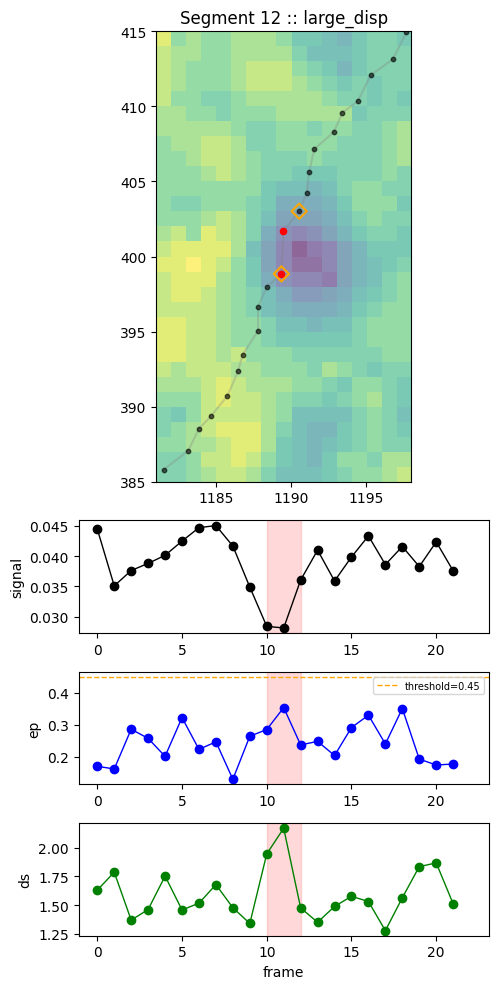

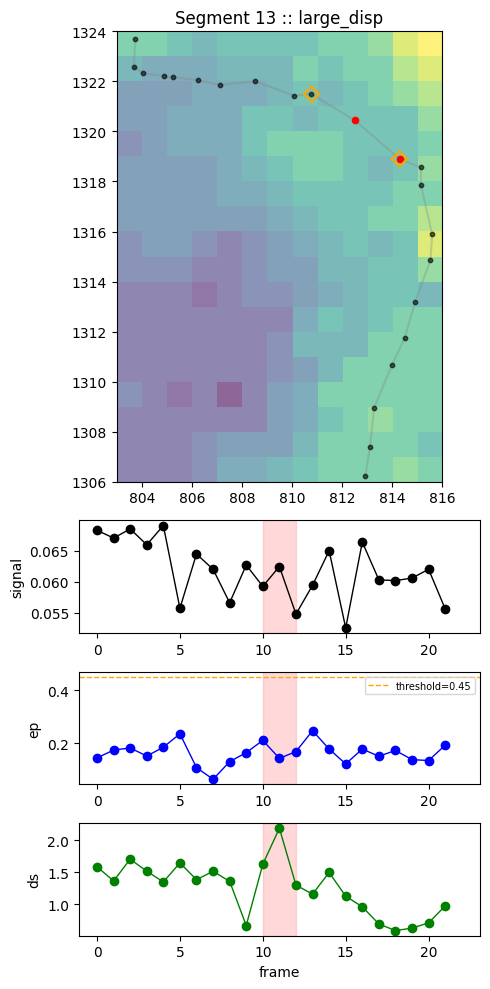

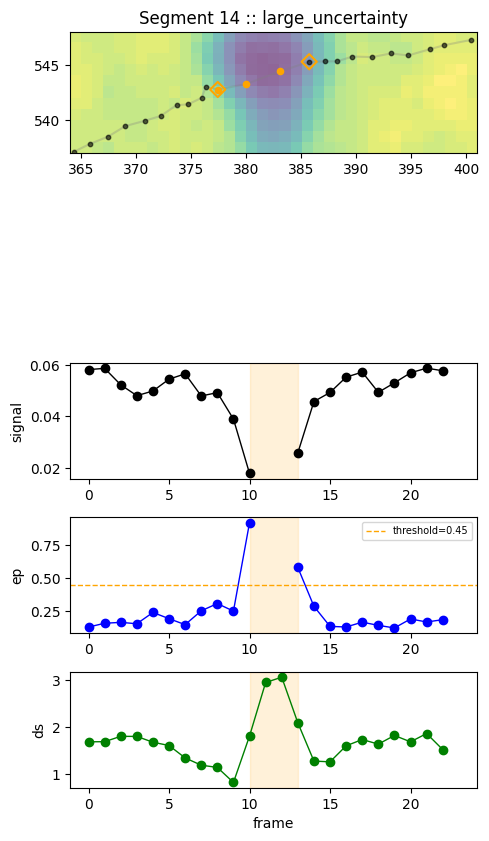

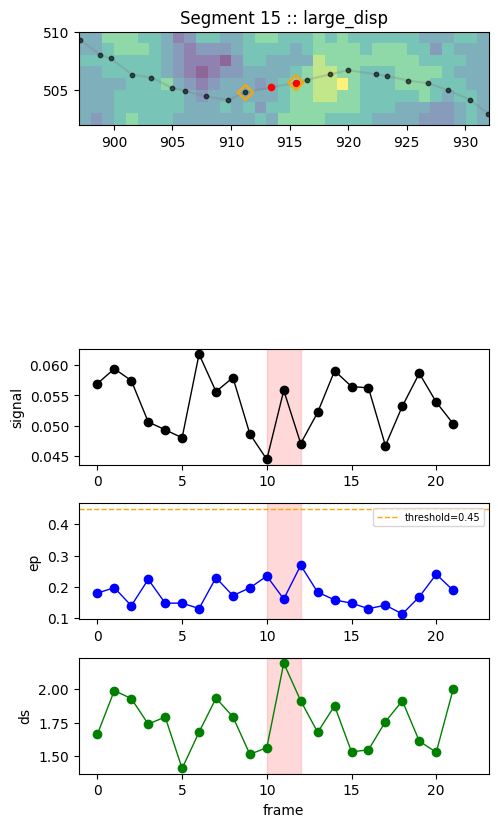

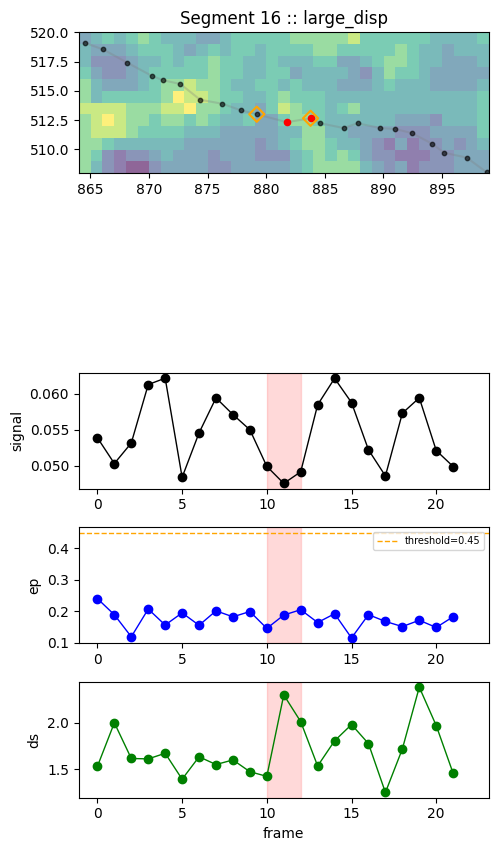

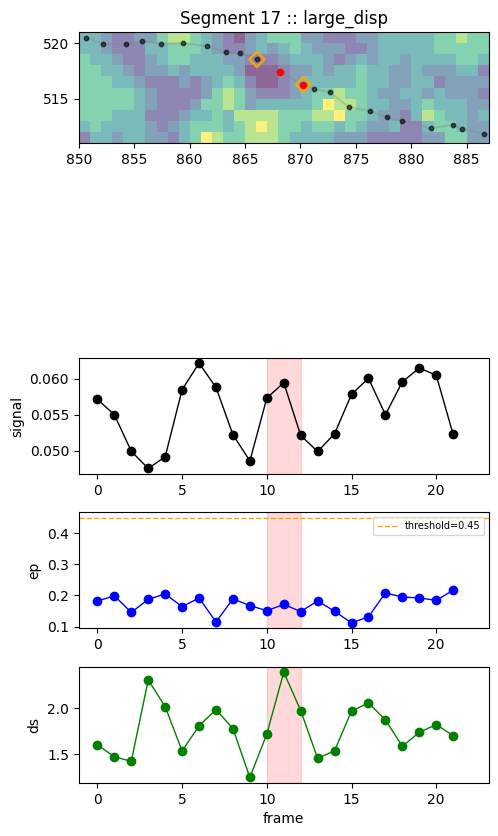

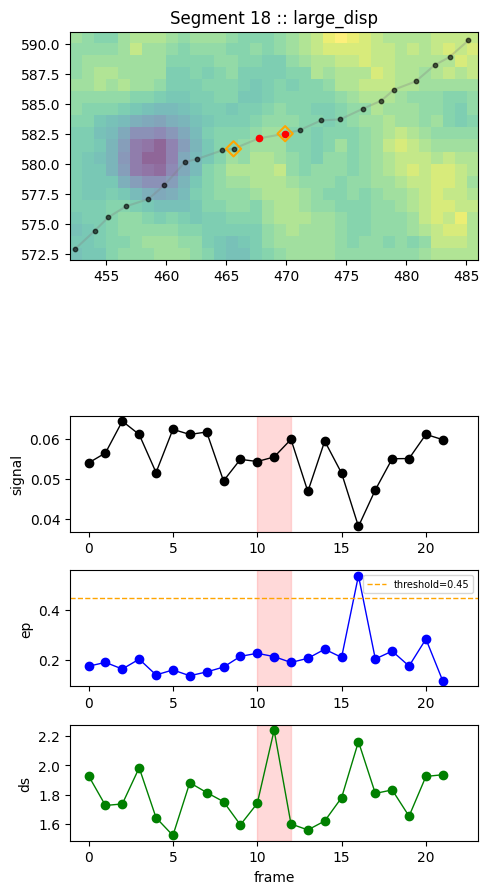

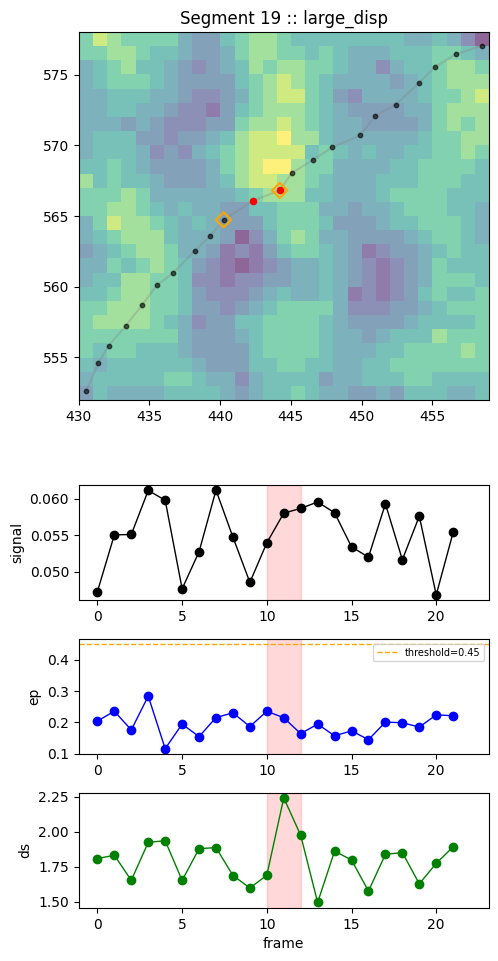

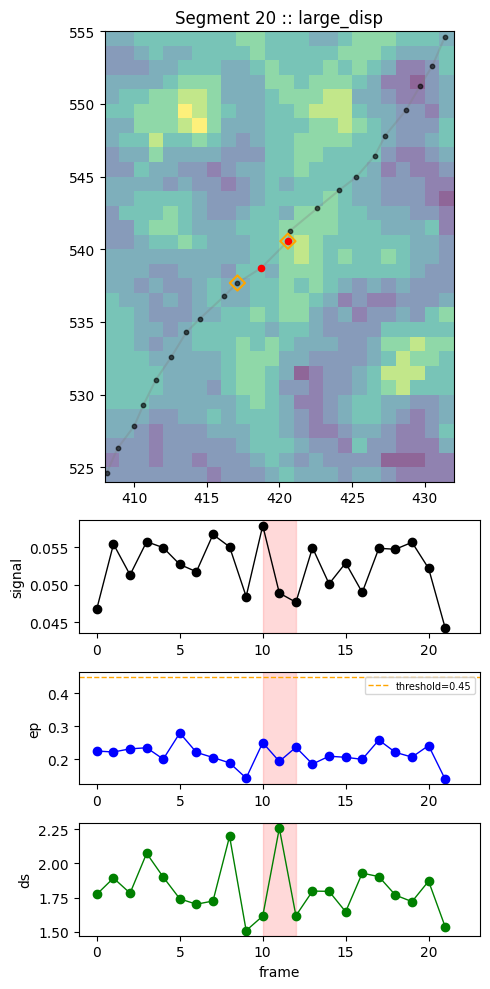

KeyboardInterrupt: 

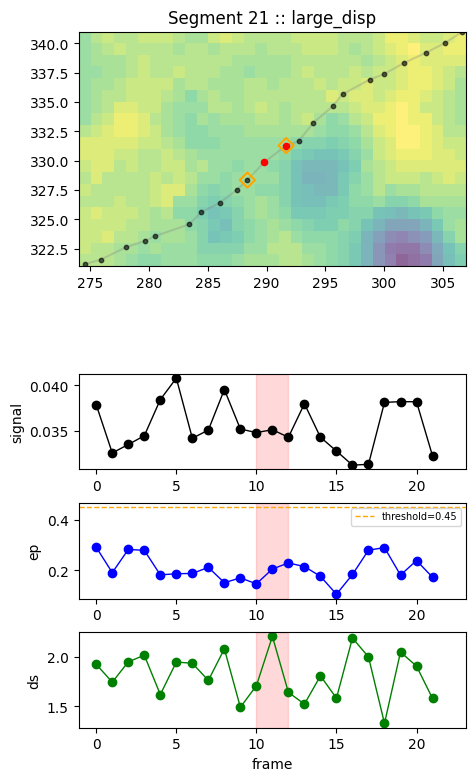

In [31]:
from analysis.outliers import plot_outlier_diagnostics_df
#plot_outlier_diagnostics_df(cell, [event for event in events if event["type"] == "large_uncertainty"], pad=10, sigcol="signal", ep_col="ep_unrefined", image=first_frame)
plot_outlier_diagnostics_df(cell, events, pad=10, sigcol="signal", ep_col="ep_unrefined", image=first_frame)


In [ ]:
def plot_event_durations(cv, events):
    df = cv.dfs["tracks"]

    t0 = np.array([e["anchor_before"] for e in events])
    t1 = np.array([e["anchor_after"] for e in events])
    durations = t1 - t0

    fig, axs = plt.subplots(
        nrows=2,
        figsize=(12, 10))

    # ----------------------------
    # 1) Event duration histogram (FIXED MODE)
    # ----------------------------
    hist_dur, bins_dur = np.histogram(durations, bins=50, density=True)
    centers_dur = 0.5 * (bins_dur[:-1] + bins_dur[1:])

    axs[0].bar(centers_dur, hist_dur, width=np.diff(bins_dur), color="black", alpha=0.7)

    mode_idx_dur = np.argmax(hist_dur)
    mode_val_dur = centers_dur[mode_idx_dur]

    axs[0].axvline(
        mode_val_dur,
        color="red",
        linestyle="--",
        label=fr"Mode ($\approx {mode_val_dur:.1f}$ frames)"
    )

    axs[0].set_xlabel("event duration (frames)")
    axs[0].set_ylabel("density")
    axs[0].set_title("Event duration histogram (50 bins)")
    axs[0].legend()

    # ----------------------------
    # 2) Inter-event durations (already correct style)
    # ----------------------------
    event_frames = np.sort(np.array([e["bad_start"] for e in events]))
    dt = np.diff(event_frames)

    hist, bins = np.histogram(dt, bins=5000, density=True)
    centers = 0.5 * (bins[:-1] + bins[1:])

    axs[1].bar(centers, hist, width=np.diff(bins), color="black", alpha=0.7)

    mode_idx = np.argmax(hist)
    mode_val = centers[mode_idx]

    axs[1].axvline(
        mode_val,
        linestyle="--",
        color="red",
        label=fr"Mode ($\Delta t \approx {mode_val:.1f}$ frames)"
    )

    axs[1].set_xlim(0, 150)
    axs[1].set_ylabel("density")
    axs[1].set_xlabel("Time gap between events (frames)")
    axs[1].set_title("Inter-event time gap histogram (5000 bins)")
    axs[1].legend()

    plt.show()

plot_event_durations(cell, events)

# Step size

+ Calculate step sizes for small time-segments (1.62 minutes for 500 segments) and calculate step-size.
+ Obtain outlier thresholds.


In [ ]:
## Define arbitrary timesegments (split trajectory into smaller groups)
#no_bins = 750 #4
no_bins = 500 
print("Time segment length", (cell().split.max()*10)/no_bins, "minutes")

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
ds = pd.DataFrame({"ds":np.hypot(np.gradient(cell().xf), np.gradient(cell().yf))})
ds["split"] = cell().split
ds["gframe"] = cell().gframe

ds["tbin"] = pd.cut(ds["gframe"], bins=no_bins, labels=False)
ds

#### MAD thresholds

In [ ]:
hists = []
steps = 0.1 ## Subpx resolution limit
bins=np.linspace(0, 5.5, num=55*10)
k=3

pivot = ds.groupby("tbin")["ds"].apply(
        lambda x: np.histogram(x, bins=bins, density=True)[0]
    )
H = np.vstack(pivot.values)


fig, ax = plt.subplots(figsize=(14, 4))
im = ax.imshow(
    H.T,
    aspect="auto",
    origin="lower",
    extent=[ds.tbin.min(), ds.tbin.max(), bins[0], bins[-1]],
)

T = H.shape[0]
x = bins[:-1]
dx = np.diff(bins)                      # bin width
x = (bins[:-1] + bins[1:]) / 2          # bin centers

med = np.zeros(T)
stds = np.zeros(T)
mad = np.zeros(T)
for i in range(T):
    h = H[i]
    cdf = np.cumsum(h)
    cdf = cdf / (cdf[-1] + 1e-12)
    med[i] = x[np.searchsorted(cdf, 0.5)]

    h = H[i].astype(float)
    p = h / (h.sum() + 1e-12)

    mean = np.sum(p * x)
    var = np.sum(p * (x - mean)**2)

    stds[i] = np.sqrt(var)
    # median already computed
    abs_dev = np.abs(x - med[i])
    mad[i] = np.sum(p * abs_dev)   # expectation of |x - median|


sigma_mad = 1.4826 * mad

ax.plot(med, c="red", linewidth=0.5, label="Median")
#ax.plot(med + (k*stds), c="white", linewidth=0.5, label=fr"Thresholds ($k=${k})")
ax.plot(med + (k*sigma_mad), c="white", linewidth=0.5, label=fr"MAD thresholds ($k=${k})")


ax.set_title("Step-size histograms")
ax.set_xlabel("Time window")
ax.set_ylabel("Step size [px]")

plt.legend()
plt.colorbar(im, ax=ax, label="density")

fig.savefig("histograms_and_thresholds.pdf", bbox_inches='tight', format="pdf")
plt.show()

#### MAD thresholds are a bit different than the usual $3 \sigma$ estimates

In [ ]:
## Divergence of MAD and 3*standard deviation based thresholds.
fig, ax = plt.subplots(figsize=(12,4))
ax.plot(med, c="red", linewidth=0.5, label="Median")
ax.plot(med + (k*stds), c="green", linewidth=0.5, label=fr"Std dev based thresholds ($k=${k})")
ax.plot(med + (k*sigma_mad), c="blue", linewidth=0.5, label=fr"MAD thresholds ($k=${k})")

plt.legend()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

fig, ax = plt.subplots(figsize=(12, 4))

T = H.shape[0]

cmap = plt.cm.viridis
norm = mpl.colors.Normalize(vmin=0, vmax=T-1)

for i in range(T):
    ax.plot(
        bins[:-1],
        H[i],
        alpha=0.3,
        color=cmap(norm(i))
    )

# create mappable for colorbar
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar = plt.colorbar(sm, ax=ax)
cbar.set_label("Time segment")

ax.set_xlim([0, 3])
ax.set_xlabel("Step size [px]")
ax.set_ylabel("density")
ax.set_title("Histogram curves over time")

plt.show()
fig.savefig("stepszie.pdf", bbox_inches='tight', format="pdf")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from copy import deepcopy

Hsmooth = deepcopy(H)

fig, ax = plt.subplots(figsize=(12, 4))

T = H.shape[0]
w = 5  # smoothing window

kernel = np.ones(w) / w

for i in range(T):
    curve = np.convolve(H[i], kernel, mode="same")
    Hsmooth[i] = curve
    ax.plot(bins[:-1], curve, alpha=0.3, color=plt.cm.viridis(i / T))

ax.set_xlabel("ds")
ax.set_ylabel("density")
ax.set_title("Smoothed histogram curves over time")

plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

T = H.shape[0]

segments = [
    (0, T // 3),
    (T // 3, 2 * T // 3),
    (2 * T // 3, T),
]

titles = ["Beginning", "Middle", "End"]

for ax, (a, b), title in zip(axs, segments, titles):
    for i in range(a, b):
        ax.plot(bins[:-1], Hsmooth[i], alpha=0.3, color=plt.cm.viridis((i - a) / (b - a + 1e-9)))
    ax.set_title(title)
    ax.set_xlabel("Step size [px]")
axs[0].set_ylabel("density")

## Set three different time-windows
axs[0].set_xlim([0,3])
axs[1].set_xlim([0,2])
axs[2].set_xlim([0,1])


plt.tight_layout()
plt.show()
fig.savefig("stepszie_3_parts.pdf", bbox_inches='tight', format="pdf")

#### Uni-modaility can be tested using the diptest

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from diptest import diptest

grouped = ds.groupby("tbin")["ds"]

tbins, dip_vals, pvals = [], [], []

for tbin, vals in grouped:
    x = vals.values

    if len(x) < 10:
        dip_vals.append(np.nan)
        pvals.append(np.nan)
    else:
        dip, p = diptest(x)
        dip_vals.append(dip)
        pvals.append(p)

    tbins.append(tbin)

tbins = np.array(tbins)
dip_vals = np.array(dip_vals)
pvals = np.array(pvals)

# threshold
alpha = 0.05
non_uni = pvals < alpha

# -------------------------------------------------
# Plot
# -------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(tbins, pvals, label="p-value")
ax.axhline(alpha, linestyle="--", label=f"threshold ({alpha})", color="r")

# mark non-unimodal bins
ax.scatter(tbins[non_uni], pvals[non_uni], s=10, c="r", label=f"Non-unimodal ($N=${sum(non_uni)})")

ax.set_xlabel("Time segment")
ax.set_ylabel("p-value")
ax.set_title("Dip test (non-unimodal test)")
ax.legend()

plt.show()
fig.savefig("diptest.pdf", bbox_inches='tight', format="pdf")

#### Normality tests are failing -- presumably because of the heavy tails

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import normaltest

grouped = ds.groupby("tbin")["ds"]

tbins, stats, pvals = [], [], []

for tbin, vals in grouped:
    x = vals.values

    if len(x) < 10:
        stats.append(np.nan)
        pvals.append(np.nan)
    else:
        stat, p = normaltest(x)
        stats.append(stat)
        pvals.append(p)

    tbins.append(tbin)

tbins = np.array(tbins)
pvals = np.array(pvals)

alpha = 0.05
non_normal = pvals < alpha

fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(tbins, pvals)
ax.axhline(alpha, linestyle="--", color="r")

ax.scatter(tbins[non_normal], pvals[non_normal], s=10, c="r")

ax.set_xlabel("tbin")
ax.set_ylabel("p-value")
ax.set_title("Normality test")

plt.show()
fig.savefig("norm_test.pdf", bbox_inches='tight', format="pdf")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import normaltest

# assume you already have:
# thresh_array aligned with tbin index (same order as grouped)

grouped = ds.groupby("tbin")["ds"]

tbins, stats, pvals = [], [], []

for i, (tbin, vals) in enumerate(grouped):
    x = vals.values

    if len(x) < 10:
        stats.append(np.nan)
        pvals.append(np.nan)
        tbins.append(tbin)
        continue

    thresh = sigma_mad[i]   # precomputed threshold

    x_filt = x[x <= thresh]

    if len(x_filt) < 10:
        stats.append(np.nan)
        pvals.append(np.nan)
    else:
        stat, p = normaltest(x_filt)
        stats.append(stat)
        pvals.append(p)

    tbins.append(tbin)

tbins = np.array(tbins)
pvals = np.array(pvals)

alpha = 0.05
non_normal = pvals < alpha

# -------------------------------------------------
# Plot
# -------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(tbins, pvals, label="p-value")
ax.axhline(alpha, linestyle="--", color="r", label=f"threshold ({alpha})")

ax.scatter(tbins[non_normal], pvals[non_normal], s=10, c="r", label="Non-normal")

ax.set_xlabel("tbin")
ax.set_ylabel("p-value")
ax.set_title("Normality test (threshold-filtered)")
ax.legend()

plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import normaltest

grouped = ds.groupby("tbin")["ds"]

tbins, stats, pvals = [], [], []

for i in range(T):
    x = Hsmooth[i]
    if len(x) < 10:
        stats.append(np.nan)
        pvals.append(np.nan)
    else:
        stat, p = normaltest(x)
        stats.append(stat)
        pvals.append(p)

    tbins.append(tbin)

pvals = np.array(pvals)

alpha = 0.05
non_normal = pvals < alpha

fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(pvals)
ax.axhline(alpha, linestyle="--", color="r")

ax.scatter(np.arange(len(pvals))[non_normal], pvals[non_normal], s=10, c="r")

ax.set_xlabel("tbin")
ax.set_ylabel("p-value")
ax.set_title("Normality test (on histogram)")

plt.show()
fig.savefig("norm_test.pdf", bbox_inches='tight', format="pdf")

In [ ]:
from statistics import median
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import normaltest

# assume:
# Hsmooth: (T, value_bins)
# bins: bin edges
# thresh_array: length T

T = Hsmooth.shape[0]
x = (bins[:-1] + bins[1:]) / 2  # bin centers

stats, pvals = [], []

for i in range(T):
    h = Hsmooth[i]

    # clip using precomputed threshold
    mask = x <= (med[i] + sigma_mad[i])
    h_clip = h[mask]

    if len(h_clip) < 10:
        stats.append(np.nan)
        pvals.append(np.nan)
    else:
        stat, p = normaltest(h_clip)
        stats.append(stat)
        pvals.append(p)

pvals = np.array(pvals)

alpha = 0.05
non_normal = pvals < alpha

fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(pvals)
ax.axhline(alpha, linestyle="--", color="r")

ax.scatter(np.arange(len(pvals))[non_normal], pvals[non_normal], s=10, c="r", label=f"Non-normal (N={sum(non_normal)})")

ax.set_xlabel("tbin")
ax.set_ylabel("p-value")
ax.set_title("Normality test (clipped histogram)")
plt.legend()
plt.show()
fig.savefig("norm_test.pdf", bbox_inches='tight', format="pdf")

# Something else

In [ ]:


def plot_event_types(cv, events, xcol="xf", ycol="yf", frame=None):
    df = cv.dfs["tracks"]
    mask_dip = [e["type"] == "large_uncertainty" for e in events]
    mask_disp = [e["type"] == "large_disp" for e in events]

    fig, (ax, ax2) = plt.subplots(figsize=(12*2, 12), ncols=2, sharey=True)
    if frame is not None:
        ax.imshow(frame, cmap="gray")
        ax2.imshow(frame, cmap="gray")


    # --- signal_dip ---
    for e, m in zip(events, mask_dip):
        if not m:
            continue

        lo = int(e["bad_start"])
        hi = int(e["bad_end"])

        ax.scatter(
            df[xcol].values[lo:hi],
            df[ycol].values[lo:hi],
            s=100, 
            facecolors="none",
            edgecolors="blue",
            alpha=0.5
        )
        ax.set_title("Signal dip events")
        ax.set_xlabel("Camera coordinate x [px]")
    # --- large_disp ---
    for e, m in zip(events, mask_disp):
        if not m:
            continue

        lo = int(e["bad_start"])
        hi = int(e["bad_end"])

        ax2.scatter(
            df[xcol].values[lo:hi],
            df[ycol].values[lo:hi],
            s=100, 
            facecolors="none",
            edgecolors="red",
        )
        ax2.set_title("Only large displacements")
        ax2.set_xlabel("Camera coordinate x [px]")
        ax.set_ylabel("Camera coordinate y [px]")


    ax.set_aspect("equal")
    ax.set_title("Events: signal_dip (blue) vs large_disp (red)")
    plt.tight_layout()
    plt.show()
plot_event_types(cell, events, frame=first_frame)

In [ ]:
sum(cell().size_unrefined.isna())

In [ ]:
fig, ax = plt.subplots(figsize=(12,4))
fig2, ax2 = plt.subplots(figsize=(12,4))

from copy import deepcopy
ep_unrefined = deepcopy(cell().ep_unrefined)

for split in cell().split.unique():
    partial = cell()[cell().split == split]
    signal = partial.signal_unrefined
    if split == 0:
        signal = partial.signal_unrefined * 128
    ## Now calculate local ep
    #ep = ((partial.size_unrefined.to_numpy()**2)*4*0.2821)/(signal.to_numpy()*17*17)
    ep = partial.size_unrefined / np.sqrt(signal)/2
    ax.plot(partial.frame, ep, linewidth=0.5, alpha=0.5, label=f"{split}-{np.nanmean(ep)}")
    ax2.plot(partial.frame, partial.ep, linewidth=0.5, alpha=0.5, label=f"{split}-{np.nanmean(partial.ep)}")
    ax.legend()
    ax2.legend()




In [ ]:
fig, ax = plt.subplots(figsize=(12,4))
for split in cell().split.unique():
    partial = cell()[cell().split == split]
    #if split ==0:
    #    ax.plot(partial.frame, partial.size_unrefined*128, linewidth=0.5, alpha=0.5, label=split)
    if split < 3:
        ax.plot(partial.frame, partial.size_unrefined, linewidth=0.5, alpha=0.5, label=split)
    plt.legend()

In [ ]:
fig, (ax, ax2) = plt.subplots(figsize=(20,8), sharex=False, nrows=2)
ax.plot(cell().ep_unrefined, linewidth=0.1)
#ax.axhline(cell().ep_unrefined.median(), linestyle="--", color="red")
#ax.axhline(cell().ep_unrefined.median() + 3*(cell().ep.std()), linestyle="--", color="red")

ax2.plot(cell().signal_unrefined, linewidth=0.1)
ax.set_ylim(0, 1)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_event_clustering(events):
    # --- extract time coordinates ---
    t_start = np.array([e["anchor_before"] for e in events])
    t_end   = np.array([e["anchor_after"] for e in events])
    t_mid   = 0.5 * (t_start + t_end)

    etype = np.array([e["type"] for e in events])

    # --- figure 1: event intervals over time ---
    fig, ax = plt.subplots(figsize=(12, 4))

    for i, e in enumerate(events):
        color = "red" if e["type"] == "large_disp" else "blue"
        ax.plot([t_start[i], t_end[i]], [i, i], color=color, alpha=0.6)

    ax.scatter(t_mid, np.arange(len(events)), c="black", s=8)

    ax.set_xlabel("frame index")
    ax.set_ylabel("event index")
    ax.set_title("Temporal clustering of events")

    plt.tight_layout()
    plt.show()

    # --- figure 2: event density over time ---
    bins = np.linspace(np.min(t_mid), np.max(t_mid), 50)
    density, _ = np.histogram(t_mid, bins=bins)

    fig, ax = plt.subplots(figsize=(12, 3))
    ax.plot(bins[:-1], density, lw=2)

    ax.set_xlabel("frame index")
    ax.set_ylabel("event count")
    ax.set_title("Event density over time")

    plt.tight_layout()
    plt.show()

plot_event_clustering(events)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_event_counts_per_split(cv, events):
    df = cv.dfs["tracks"]

    # map frame index -> split
    gframe = df["gframe"].values
    split_map = df["split"].values

    # extract event frame positions
    event_frame = np.array([e["anchor_before"] for e in events])
    event_type  = np.array([e["type"] for e in events])

    # convert frame -> split via gframe match
    frame_to_split = dict(zip(gframe, split_map))
    splits = np.array([frame_to_split.get(f, -1) for f in event_frame])

    unique_splits = np.sort(np.unique(splits))

    large_counts = []
    dip_counts = []

    for s in unique_splits:
        mask = splits == s
        large_counts.append(np.sum(mask & (event_type == "large_disp")))
        dip_counts.append(np.sum(mask & (event_type == "signal_dip")))

    large_counts = np.array(large_counts)
    dip_counts = np.array(dip_counts)

    fig, ax = plt.subplots(figsize=(10, 4))

    ax.plot(unique_splits, large_counts, color="red", label="large_disp")
    ax.plot(unique_splits, dip_counts, color="blue", label="signal_dip")

    ax.set_xlabel("split")
    ax.set_ylabel("number of events")
    ax.set_title("Event counts per split (mapped via gframe)")
    ax.legend()

    plt.tight_layout()
    plt.show()
plot_event_counts_per_split(cell, events)

# View Data

In [ ]:
#%%time
from trappytv import TrappyTV
tv = TrappyTV(cell, width=81000, height=1000, filtered_columns={   "filled": ["xf_", "yf_"],
                                                                  "filtered": ["xf", "yf"],
                                                                  "denoised": ["xf_11Hz", "yf_11Hz"],
                                                                  "anti-aliased": ["xf_3Hz", "yf_3Hz"],
                                                                  "long-term": ["xf_long", "yf_long"]})
tv.view_split(split_no=0)    ## Show only a particular split -> render all points
#tv.view_all(sample=10)    ## Show only a particular split -> render all points


In [ ]:
def plot_outlier_frequency_time(cv, events, bins=50):
    df = cv.dfs["tracks"]

    # map events → frame positions
    starts = np.array([e["bad_start"] for e in events])
    ends   = np.array([e["bad_end"] for e in events])
    types  = np.array([e["type"] for e in events])

    # event center as proxy time
    centers = (starts + ends) / 2

    fig, ax = plt.subplots(figsize=(10, 4))

    ax.hist(centers, bins=bins, alpha=0.7)

    ax.set_title("Outlier event frequency over time")
    ax.set_xlabel("frame")
    ax.set_ylabel("event count")

    plt.tight_layout()
    plt.show()
plot_outlier_frequency_time(cell, events)